## Cell 1 - Verify GPU


In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "No GPU found. Change runtime type to T4 GPU.")


Tue Apr 28 14:54:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 - Install Dependencies


In [2]:
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes datasets


## Cell 3 - Imports

In [3]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM total      : 15.6 GB


## Cell 4 - Hyperparameters
All training configuration is defined here in one place so it is easy to change and document.

| Hyperparameter | Value | Reason |
|---|---|---|
| `MAX_SEQ_LENGTH` | 512 | Covers all our Q&A pairs with room to spare |
| `LOAD_IN_4BIT` | True | QLoRA: quantise base model to 4-bit to save VRAM |
| `LORA_R` | 16 | LoRA rank — controls adapter capacity |
| `LORA_ALPHA` | 16 | Scaling factor (equal to r is standard) |
| `LORA_DROPOUT` | 0.05 | Small dropout for regularisation |
| `LEARNING_RATE` | 2e-4 | Standard QLoRA learning rate |
| `BATCH_SIZE` | 2 | Small batch fits T4 VRAM |
| `GRAD_ACCUM` | 4 | Effective batch = 2×4 = 8 |
| `EPOCHS` | 3 | Enough for 88 training samples to converge |
| `WARMUP_STEPS` | 5 | Short warmup for small dataset |
| `WEIGHT_DECAY` | 0.01 | Mild L2 regularisation |
| `OPTIMIZER` | adamw_8bit | Memory-efficient AdamW |


In [4]:
# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME     = "unsloth/Llama-3.2-1B-Instruct"
MAX_SEQ_LENGTH = 512
LOAD_IN_4BIT   = True

# ── LoRA adapter ──────────────────────────────────────────────────────────────
LORA_R         = 16
LORA_ALPHA     = 16
LORA_DROPOUT   = 0.05

# ── Training ──────────────────────────────────────────────────────────────────
LEARNING_RATE  = 2e-4
BATCH_SIZE     = 2
GRAD_ACCUM     = 4
EPOCHS         = 3
WARMUP_STEPS   = 5
WEIGHT_DECAY   = 0.01
OPTIMIZER      = "adamw_8bit"
LR_SCHEDULER   = "linear"

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR     = "/content/infosec-lora"
GGUF_DIR       = "/content/infosec-gguf_gguf"
GGUF_QUANT     = "q4_k_m"

print("Hyperparameters set.")


Hyperparameters set.


## Cell 5 - Load Base Model and Tokenizer



In [5]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = None,
    load_in_4bit    = LOAD_IN_4BIT,
)
print(f"   Model loaded: {MODEL_NAME}")
print(f"   Parameters  : ~1B")
print(f"   Quantisation: 4-bit (QLoRA)")


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


   Model loaded: unsloth/Llama-3.2-1B-Instruct
   Parameters  : ~1B
   Quantisation: 4-bit (QLoRA)


## Cell 6 - Apply LoRA Adapters


In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r                   = LORA_R,
    target_modules      = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha          = LORA_ALPHA,
    lora_dropout        = LORA_DROPOUT,
    bias                = "none",
    use_gradient_checkpointing = "unsloth",
    random_state        = 42,
    use_rslora          = False,
    loftq_config        = None,
)


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"   LoRA adapters applied.")
print(f"   Trainable parameters : {trainable:,}  ({100*trainable/total:.2f}% of total)")
print(f"   Frozen parameters    : {total - trainable:,}")
print(f"   Total parameters     : {total:,}")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


   LoRA adapters applied.
   Trainable parameters : 11,272,192  (1.43% of total)
   Frozen parameters    : 774,440,960
   Total parameters     : 785,713,152


## Cell 7 - Load and Format Dataset



In [7]:
# ── Upload your JSONL files to Colab ─────────────────────────────────────────
from google.colab import files
print("Upload infosec_train.jsonl and infosec_val.jsonl when prompted...")
uploaded = files.upload()
print(f"Uploaded: {list(uploaded.keys())}")


Upload infosec_train.jsonl and infosec_val.jsonl when prompted...


Saving infosec_val.jsonl to infosec_val.jsonl
Saving infosec_train.jsonl to infosec_train.jsonl
Uploaded: ['infosec_val.jsonl', 'infosec_train.jsonl']


In [8]:
# ── Define the prompt template ────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a knowledgeable and helpful information security expert. "
    "Answer questions clearly, accurately, and concisely."
)

EOS_TOKEN = tokenizer.eos_token

def format_example(example):
    """Convert a single instruction/response pair into the Llama-3 chat format."""
    text = (
        f"<|begin_of_text|>"
        f"<|start_header_id|>system<|end_header_id|>\n\n{SYSTEM_PROMPT}<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n{example['instruction']}<|eot_id|>"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n{example['response']}{EOS_TOKEN}"
    )
    return {"text": text}

# ── Load JSONL files ──────────────────────────────────────────────────────────
def load_jsonl(path):
    with open(path) as f:
        records = [json.loads(l) for l in f if l.strip()]
    return Dataset.from_list(records)

train_raw = load_jsonl("/content/infosec_train.jsonl")
val_raw   = load_jsonl("/content/infosec_val.jsonl")

# Apply formatting
train_dataset = train_raw.map(format_example)
val_dataset   = val_raw.map(format_example)

print(f"✅ Dataset formatted.")
print(f"   Train samples : {len(train_dataset)}")
print(f"   Val samples   : {len(val_dataset)}")
print(f"\nSample formatted text (first 300 chars):")
print(train_dataset[0]['text'][:300])


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

✅ Dataset formatted.
   Train samples : 88
   Val samples   : 11

Sample formatted text (first 300 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledgeable and helpful information security expert. Answer questions clearly, accurately, and concisely.<|eot_id|><|start_header_id|>user<|end_header_id|>

What is DEF CON?<|eot_id|><|start_header_id|>assistant<|end_header_id|


## Cell 8 - Configure and Run the Trainer



In [9]:
trainer = SFTTrainer(
    model            = model,
    tokenizer        = tokenizer,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    dataset_text_field = "text",
    max_seq_length   = MAX_SEQ_LENGTH,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size  = BATCH_SIZE,
        gradient_accumulation_steps  = GRAD_ACCUM,
        num_train_epochs             = EPOCHS,
        warmup_steps                 = WARMUP_STEPS,
        learning_rate                = LEARNING_RATE,
        weight_decay                 = WEIGHT_DECAY,
        optim                        = OPTIMIZER,
        lr_scheduler_type            = LR_SCHEDULER,
        fp16                         = not is_bfloat16_supported(),
        bf16                         = is_bfloat16_supported(),
        logging_steps                = 5,
        eval_strategy                = "epoch",
        save_strategy                = "epoch",
        output_dir                   = OUTPUT_DIR,
        report_to                    = "none",
        seed                         = 42,
    ),
)

print("✅ Trainer configured. Starting training...")
print(f"   Effective batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"   Training samples     : {len(train_dataset)}")
print(f"   Epochs               : {EPOCHS}")


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/88 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/11 [00:00<?, ? examples/s]

✅ Trainer configured. Starting training...
   Effective batch size : 8
   Training samples     : 88
   Epochs               : 3


In [10]:
# ── Start training ────────────────────────────────────────────────────────────

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   Final training loss : {train_result.training_loss:.4f}")
print(f"   Total steps         : {train_result.global_step}")


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 88 | Num Epochs = 3 | Total steps = 33
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,1.858591,1.373912
2,1.170027,1.231623
3,1.030233,1.213792


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✅ Training complete!
   Final training loss : 1.4854
   Total steps         : 33


## Cell 9 - Plot Training Loss Curve



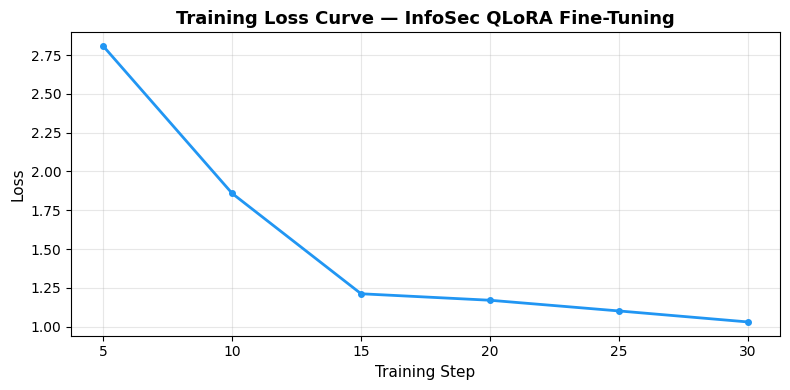

✅ Loss curve saved to /content/training_loss_curve.png


In [11]:

log_history = trainer.state.log_history
steps  = [x["step"] for x in log_history if "loss" in x]
losses = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, color="#2196F3", linewidth=2, marker="o", markersize=4)
plt.title("Training Loss Curve — InfoSec QLoRA Fine-Tuning", fontsize=13, fontweight="bold")
plt.xlabel("Training Step", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/training_loss_curve.png", dpi=150)
plt.show()
print("✅ Loss curve saved to /content/training_loss_curve.png")


## Cell 10 - Base Model vs Fine-Tuned Comparison


In [12]:
def ask(model, tokenizer, question, max_new_tokens=200):
    """Run inference with the Llama-3 chat template and return the response text."""
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": question},
    ]

    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens = max_new_tokens,
            temperature    = 0.1,
            do_sample      = True,
            pad_token_id   = tokenizer.eos_token_id,
        )
    #
    new_tokens = output_ids[0][input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


TEST_PROMPTS = [
    "What is the CIA triad in information security?",
    "What is a man-in-the-middle attack?",
    "What is the principle of least privilege?",
]

# ── Enable fine-tuned inference mode ─────────────────────────────────────────
FastLanguageModel.for_inference(model)

print("=" * 70)
print("FINE-TUNED MODEL RESPONSES")
print("=" * 70)
ft_responses = []
for q in TEST_PROMPTS:
    resp = ask(model, tokenizer, q)
    ft_responses.append(resp)
    print(f"\nQ: {q}")
    print(f"A: {resp}")
    print("-" * 70)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINE-TUNED MODEL RESPONSES


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i


Q: What is the CIA triad in information security?
A: The CIA triad is a fundamental concept in information security. It consists of three components: 

1. Confidentiality: Protecting sensitive information from unauthorized access.
2. Integrity: Ensuring data is accurate and not modified without authorization.
3. Availability: Ensuring data is accessible when needed, despite disruptions.

These three pillars are interconnected and must be maintained simultaneously to ensure effective security.
----------------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is a man-in-the-middle attack?
A: A man-in-the-middle (MITM) attack is a type of social engineering attack where an attacker intercepts communication between two parties, pretending to be the other party. This can be done by physically blocking the communication channel or by manipulating the data being transmitted.
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Q: What is the principle of least privilege?
A: The principle of least privilege (PoLP) is a security best practice that states users should have only the privileges necessary to perform their job tasks. It ensures that users can only access resources they need to perform their job functions, reducing the attack surface.
----------------------------------------------------------------------


In [13]:
# ── Load the original base model for comparison ───────────────────────────────

print("Loading base model for comparison (no LoRA)...")
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name   = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype        = None,
    load_in_4bit = LOAD_IN_4BIT,
)
FastLanguageModel.for_inference(base_model)

print("=" * 70)
print("BASE MODEL RESPONSES (no fine-tuning)")
print("=" * 70)
for q in TEST_PROMPTS:
    resp = ask(base_model, base_tokenizer, q)
    print(f"\nQ: {q}")
    print(f"A: {resp}")
    print("-" * 70)


Loading base model for comparison (no LoRA)...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL RESPONSES (no fine-tuning)


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is the CIA triad in information security?
A: The CIA triad is a fundamental concept in information security that refers to the three essential components of a secure information system. These components are:

1. **Confidentiality**: This refers to the protection of sensitive information from unauthorized access, use, or disclosure. It ensures that only authorized individuals or systems can access and use the information.

2. **Integrity**: This component ensures that data is not altered, corrupted, or modified without authorization. It guarantees that the data remains accurate, complete, and unchanged.

3. **Availability**: This refers to the assurance that the information is accessible and can be used when needed. It ensures that the system is operational, and the data is available to authorized users.

The CIA triad is often depicted as a triangle, with each component forming a corner of the triangle. It is a cornerstone of information security best practices and is widely a

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is a man-in-the-middle attack?
A: A man-in-the-middle (MITM) attack is a type of cyber attack where an attacker intercepts and alters communication between two parties, often for malicious purposes. In the context of the internet, a MITM attack typically involves an attacker positioning themselves between the victim (the person or organization being targeted) and the intended recipient (the other party in the communication).

Here's how it works:

1. The attacker sets up a fake or compromised device (e.g., a computer, smartphone, or router) that appears to be connected to the victim's device.
2. The attacker intercepts the communication between the victim and the intended recipient, often by spoofing the victim's IP address or using a man-in-the-middle (MITM) proxy.
3. The attacker alters the communication, often to steal sensitive information, inject malware, or send spam.

Common examples of MITM attacks include:

* Phishing: an attacker sends fake emails that appear to be f

## Cell 11 - Save the LoRA Adapter


In [14]:
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✅ LoRA adapter saved to: {OUTPUT_DIR}")

import os
files_saved = os.listdir(OUTPUT_DIR)
print(f"   Files: {files_saved}")


Unsloth: Restored added_tokens_decoder metadata in /content/infosec-lora/tokenizer_config.json.


✅ LoRA adapter saved to: /content/infosec-lora
   Files: ['chat_template.jinja', 'tokenizer.json', 'adapter_config.json', 'checkpoint-33', 'tokenizer_config.json', 'checkpoint-11', 'README.md', 'checkpoint-22', 'adapter_model.safetensors']


## Cell 12 - Export to GGUF



In [15]:
import os
os.makedirs(GGUF_DIR, exist_ok=True)


model.save_pretrained_gguf(
    GGUF_DIR,
    tokenizer,
    quantization_method = GGUF_QUANT,
)
print(f"✅ GGUF model exported to: {GGUF_DIR}")


for f in os.listdir(GGUF_DIR):
    size_mb = os.path.getsize(os.path.join(GGUF_DIR, f)) / 1e6
    print(f"   {f}  ({size_mb:.1f} MB)")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/infosec-gguf_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:39<00:00, 39.55s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:28<00:00, 28.24s/it]


Unsloth: Merge process complete. Saved to `/content/infosec-gguf_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /content/infosec-gguf_gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/infosec-gguf_gguf_gguf/Modelfile
✅ GGUF model exported to: /content/infosec-gguf_gguf
   chat_template.jinja  (0.0 MB)
   tokenizer.json  (17.2 MB)
   .cache  (0.0 MB)
   tokenizer_config.json  (0.1 MB)
   config

In [16]:
from unsloth import FastLanguageModel


model.save_pretrained_gguf(
    GGUF_DIR,
    tokenizer,
    quantization_method="q8_0"
)

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 6932.73it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:37<00:00, 37.45s/it]


Unsloth: Merge process complete. Saved to `/content/infosec-gguf_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q8_0'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q8_0. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.Q8_0.gguf']
Unsloth: exampl

{'save_directory': '/content/infosec-gguf_gguf',
 'gguf_directory': '/content/infosec-gguf_gguf_gguf',
 'gguf_files': ['/content/infosec-gguf_gguf_gguf/llama-3.2-1b-instruct.Q8_0.gguf'],
 'modelfile_location': '/content/infosec-gguf_gguf_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

## Cell 13 - Upload GGUF to Hugging Face Hub



In [17]:
from huggingface_hub import HfApi, login
from google.colab import userdata
import os


HF_TOKEN    = userdata.get('group1-token')
HF_USERNAME = "Mahmoud-Alsakhawy"
REPO_NAME   = "infosec-llama3-qlora-gguf"

login(token=HF_TOKEN)
api = HfApi()


repo_id = f"{HF_USERNAME}/{REPO_NAME}"
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)


for filename in os.listdir(GGUF_DIR):
    if filename == ".cache":
        print(f"Skipping {filename} ...")
        continue
    local_path = os.path.join(GGUF_DIR, filename)
    print(f"Uploading {filename} ...")
    api.upload_file(
        path_or_fileobj = local_path,
        path_in_repo    = filename,
        repo_id         = repo_id,
        repo_type       = "model",
    )

print(f"\n✅ GGUF model uploaded to: https://huggingface.co/{repo_id}")
print("Copy this URL — you will need it in Step 6 (EC2 deployment).")

Uploading chat_template.jinja ...
Uploading tokenizer.json ...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-gguf_gguf/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

Skipping .cache ...
Uploading tokenizer_config.json ...
Uploading config.json ...
Uploading model.safetensors ...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uf_gguf/model.safetensors:   1%|          | 24.0MB / 2.47GB            


✅ GGUF model uploaded to: https://huggingface.co/Mahmoud-Alsakhawy/infosec-llama3-qlora-gguf
Copy this URL — you will need it in Step 6 (EC2 deployment).


## Cell 14 - Download Files to Your Computer



In [18]:
from google.colab import files
import shutil


files.download("/content/training_loss_curve.png")


shutil.make_archive("/content/infosec-lora", "zip", OUTPUT_DIR)
files.download("/content/infosec-lora.zip")

print("✅ Downloads started. Check your browser's download folder.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started. Check your browser's download folder.
